# Crypto Price Prediction — All-in-one Colab notebook

**Version 7** — Same as v6 plus: **returns-based targets** (Ridge + baselines predict next-day return), **directional accuracy on returns** (exclude zero change), **volatility per-split** (no leakage), **TimeSeriesSplit gap=21**, **single-layer LSTM + dropout**, **long/short backtest with transaction costs**. Asset: set `ASSET` in the next cell (e.g. `BTC-USD`, `ETH-USD`, `XRP-USD`, `ETC-USD`). One notebook, one version.

**Upload to Colab and run all cells.** Optional: Runtime → Change runtime type → GPU for faster LSTM.

*Versioning: pipeline versions only (v4 → v5 → v6 → v7…). When you add a new pipeline revision, move this file to `archive/` and create the next version. See `notebooks/README.md`.*

In [1]:
# === CONFIG: change asset here (not a new version — just a variation) ===
ASSET = "ETC-USD"   # e.g. "ETH-USD", "XRP-USD", "ETC-USD"

In [2]:
# Run this cell first: install packages (takes ~1 min)
!pip install -q pandas numpy yfinance pyarrow scikit-learn tensorflow matplotlib

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
from pathlib import Path
import matplotlib.pyplot as plt

def regression_metrics(y_true, y_pred):
    """MAE and RMSE on same-scale targets (prices or returns)."""
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return {"mae": float(mae), "rmse": float(rmse)}


def directional_accuracy_returns(y_true_ret, y_pred_ret, zero_threshold=1e-10):
    """
    Directional accuracy on returns: sign(actual) vs sign(predicted).
    Exclude cases where either actual or predicted return is ~0 (no meaningful direction).
    """
    y_true_ret = np.asarray(y_true_ret).ravel()
    y_pred_ret = np.asarray(y_pred_ret).ravel()
    mask = (np.abs(y_true_ret) > zero_threshold) & (np.abs(y_pred_ret) > zero_threshold)
    if mask.sum() == 0:
        return np.nan
    true_dir = np.sign(y_true_ret[mask])
    pred_dir = np.sign(y_pred_ret[mask])
    return float(np.mean(true_dir == pred_dir))


def metrics_from_returns(y_true_ret, y_pred_ret, zero_threshold=1e-10):
    """Full metrics when predicting returns: MAE, RMSE (on returns), and directional (exclude zero change)."""
    out = regression_metrics(y_true_ret, y_pred_ret)
    out["directional_accuracy"] = directional_accuracy_returns(y_true_ret, y_pred_ret, zero_threshold)
    return out

# Data folder: Colab uses /content; local uses .
DATA_DIR = Path('/content/data') if Path('/content').exists() else Path('./data')
DATA_DIR.mkdir(exist_ok=True)
print("Ready. DATA_DIR =", DATA_DIR)

Ready. DATA_DIR = /content/data


---
## 1. Download data and split (70 / 15 / 15)

In [4]:
cache_name = ASSET.replace("-", "_") + "_daily.parquet"
cache_path = DATA_DIR / cache_name
if cache_path.exists():
    df = pd.read_parquet(cache_path)
    print("Loaded from cache:", cache_path, "| ASSET =", ASSET)
else:
    raw = yf.download(ASSET, start="2017-01-01", end=None, progress=False, auto_adjust=True)
    if raw.index.nlevels > 1:
        raw = raw.reset_index(level=1, drop=True)
    raw.index = pd.to_datetime(raw.index).tz_localize(None)
    raw = raw.sort_index().ffill().dropna()
    df = raw[["Close"]].copy()
    df.columns = ["price"]
    if "Volume" in raw.columns:
        df["volume"] = raw["Volume"]
    df.to_parquet(cache_path)
    print("Downloaded and saved:", cache_path)

# Ensure volume exists (use 0 if missing)
if "volume" not in df.columns:
    df["volume"] = 0.0
# Returns (day-over-day): first row is NaN (no previous day), fill with 0
df["ret"] = (df["price"] - df["price"].shift(1)) / (df["price"].shift(1) + 1e-12)
df["ret"] = df["ret"].fillna(0.0)
# Log volume for scale
df["log_volume"] = np.log1p(df["volume"])
# Volatility: computed per-split in model code to avoid leakage (train uses only train data)
df = df.copy()

n = len(df)
train_end = int(0.70 * n)
val_end = int(0.85 * n)
train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]
print(df.shape, "| Train", len(train_df), "Val", len(val_df), "Test", len(test_df))

Downloaded and saved: /content/data/ETC_USD_daily.parquet
(3033, 4) | Train 2123 Val 455 Test 455


---
## 2. Baselines (last value, 7-day MA)

In [5]:
# Baselines in return space (aligned with Ridge/LSTM: we predict next-day return)
prices = test_df["price"].values
rets_test = test_df["ret"].values[1:]  # next-day returns (align with price[1:])
price_prev = prices[:-1]  # previous day price for each prediction
# Last value: predict no change -> predicted return = 0
pred_ret_last = np.zeros_like(rets_test)
m_last = metrics_from_returns(rets_test, pred_ret_last)

# 7-day MA: predicted price = MA of last 7; predicted return = (pred_price - price_prev) / price_prev
window = 7
pred_price_ma = np.array([np.mean(prices[i - window : i]) for i in range(window, len(prices))])
price_prev_ma = prices[window - 1 : -1]
pred_ret_ma = (pred_price_ma - price_prev_ma) / (price_prev_ma + 1e-12)
y_true_ma = rets_test[window - 1 :]
m_ma = metrics_from_returns(y_true_ma, pred_ret_ma)

print("Last value (pred ret=0):", m_last)
print("7-day MA:  ", m_ma)

Last value (pred ret=0): {'mae': 0.03016076625868902, 'rmse': 0.04238245706425545, 'directional_accuracy': 0.0}
7-day MA:   {'mae': 0.046755070573145825, 'rmse': 0.06323689162953018, 'directional_accuracy': 0.5558035714285714}


---
## 3. Lag model (Ridge + 30 lags)

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

N_LAGS = 30
price_full = df["price"].values
ret_full = df["ret"].values
log_vol_full = df["log_volume"].values

def build_lag_features(price, n_lags, ret=None):
    """Build lag features from returns when predicting returns, from prices when predicting prices."""
    T = len(price)
    if ret is not None:
        # Use return lags as features when predicting returns (same scale, stationary)
        X_list = [ret[n_lags - lag : T - lag] for lag in range(1, n_lags + 1)]
        X = np.column_stack(X_list)[:-1]
        y = ret[n_lags + 1 :]
    else:
        X_list = [price[n_lags - lag : T - lag] for lag in range(1, n_lags + 1)]
        X = np.column_stack(X_list)[:-1]
        y = price[n_lags + 1 :]
    return X, y

# Volatility per-split to avoid leakage: train uses only train data; val/test use causal rolling on history
def volatility_causal(ret_series):
    return np.nan_to_num(pd.Series(ret_series).rolling(14).std().values, nan=0.0)

X_train, y_train = build_lag_features(train_df["price"].values, N_LAGS, ret=train_df["ret"].values)
X_val, y_val = build_lag_features(val_df["price"].values, N_LAGS, ret=val_df["ret"].values)
X_test, y_test = build_lag_features(test_df["price"].values, N_LAGS, ret=test_df["ret"].values)

# Train vol: from train_df only (no val/test leakage). Val/test: causal rolling on df up to that point.
vol_train = volatility_causal(train_df["ret"].values)[N_LAGS : N_LAGS + len(y_train)]
vol_full = volatility_causal(df["ret"].values)  # for val/test: causal at each index
vol_val = vol_full[train_end + N_LAGS : train_end + N_LAGS + len(y_val)]
vol_test = vol_full[val_end + N_LAGS : val_end + N_LAGS + len(y_test)]

def add_vol_volatility_split(X, y, log_vol_slice, vol_slice):
    n = len(y)
    extra = np.column_stack([log_vol_slice[:n], vol_slice[:n]])
    return np.hstack([X, extra])

lv_train = log_vol_full[N_LAGS : N_LAGS + len(y_train)]
lv_val = log_vol_full[train_end + N_LAGS : train_end + N_LAGS + len(y_val)]
lv_test = log_vol_full[val_end + N_LAGS : val_end + N_LAGS + len(y_test)]

X_train = add_vol_volatility_split(X_train, y_train, lv_train, vol_train)
X_val   = add_vol_volatility_split(X_val, y_val, lv_val, vol_val)
X_test  = add_vol_volatility_split(X_test, y_test, lv_test, vol_test)

n_f = X_train.shape[1]
pipe = Pipeline([
    ("scale", ColumnTransformer([("s", StandardScaler(), list(range(n_f)))], remainder="passthrough")),
    ("ridge", Ridge(alpha=1.0)),
])
pipe.fit(X_train, y_train)
pred_lag_ret = pipe.predict(X_test)
m_lag = metrics_from_returns(y_test, pred_lag_ret)
print("Lag+Ridge (+ volume, volatility_14), target=returns:", m_lag)

Lag+Ridge (+ volume, volatility_14), target=returns: {'mae': 0.029586355800606274, 'rmse': 0.04148579171296126, 'directional_accuracy': 0.5047169811320755}


---
## 3b. Rolling backtest (Lag+Ridge)

Train on past only, predict next day, roll forward. No future leakage. Uses same features (30 lags + log_volume + volatility_14).

In [7]:
def rolling_backtest_lag(df, n_lags, model_factory, min_train=500):
    """Rolling backtest: at each end, train on past only (predict next-day return). No future leakage. Volatility from slice only."""
    price = df["price"].values
    log_vol = df["log_volume"].values
    T = len(price)
    preds_ret, actuals_ret = [], []
    for end in range(min_train + n_lags + 1, T):
        p_slice = price[:end]
        lv_slice = log_vol[:end]
        ret_slice = np.zeros(end)
        ret_slice[1:] = (p_slice[1:] - p_slice[:-1]) / (p_slice[:-1] + 1e-12)
        v_slice = volatility_causal(ret_slice)
        X_tr, y_tr = build_lag_features(p_slice, n_lags, ret=ret_slice)
        v_tr = v_slice[N_LAGS : N_LAGS + len(y_tr)]
        lv_tr = lv_slice[N_LAGS : N_LAGS + len(y_tr)]
        X_tr = np.hstack([X_tr, np.column_stack([lv_tr, v_tr])])
        model = model_factory(X_tr.shape[1])
        model.fit(X_tr, y_tr)
        # last_row: return lags (most recent n_lags returns) + log_vol + vol
        last_row = np.hstack([ret_slice[end - 1 - n_lags : end - 1][::-1], [lv_slice[end - 1], v_slice[end - 1]]]).reshape(1, -1)
        preds_ret.append(model.predict(last_row)[0])
        actuals_ret.append((price[end] - price[end - 1]) / (price[end - 1] + 1e-12))
    return np.array(preds_ret), np.array(actuals_ret)

def make_lag_pipe(n_features):
    return Pipeline([
        ("scale", ColumnTransformer([("s", StandardScaler(), list(range(n_features)))], remainder="passthrough")),
        ("ridge", Ridge(alpha=1.0)),
    ])

backtest_pred_ret, backtest_actual_ret = rolling_backtest_lag(df, N_LAGS, make_lag_pipe, min_train=500)
m_roll = metrics_from_returns(backtest_actual_ret, backtest_pred_ret)
print("Rolling backtest (Lag+Ridge, target=returns, vol per-split):", m_roll)

Rolling backtest (Lag+Ridge, target=returns, vol per-split): {'mae': 0.036073213778569695, 'rmse': 0.05799430516095268, 'directional_accuracy': 0.5111910471622702}


---
## 3c. TimeSeriesSplit + RandomizedSearchCV

Tune Ridge alpha with time-series cross-validation. Param grid: alpha in logspace.

In [8]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# Expanding window CV with 21-day gap between train and test to reduce overlap/optimism
tscv = TimeSeriesSplit(n_splits=5, gap=21)
param_grid = {"ridge__alpha": np.logspace(-2, 2, 20)}
search = RandomizedSearchCV(
    pipe, param_distributions=param_grid, n_iter=10, cv=tscv,
    scoring="neg_mean_absolute_error", random_state=42
)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV MAE (on returns):", -search.best_score_)

Best params: {'ridge__alpha': np.float64(61.584821106602604)}
Best CV MAE (on returns): 0.03836010842728808


---
## 3d. Evaluation: residual plots and error discussion

Best Lag+Ridge model on test set; residual distribution and predicted vs actual. Short note on where the model performs poorly.

Test set (best Lag+Ridge from CV, target=returns): {'mae': 0.029414881209196837, 'rmse': 0.04142354217174904, 'directional_accuracy': 0.5306603773584906}


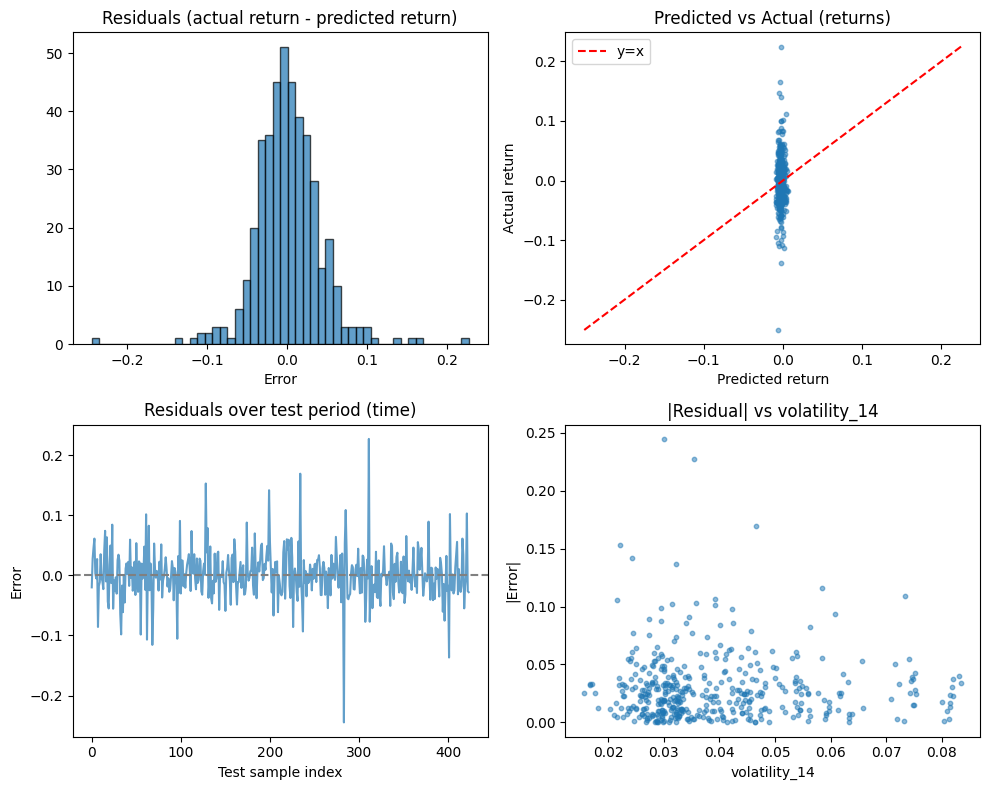

Where the model performs poorly:
- Residuals are centered near 0 but have long tails; large errors occur in both directions.
- Residuals-over-time: errors cluster in periods (volatility regimes), not uniformly.
- |Residual| vs volatility: larger errors tend to occur when volatility_14 is high.
Conclusion: The model performs worst during high-volatility periods and on large price moves; it is effectively a smoothed extrapolation of recent lags and under/overpredicts sharp moves.
Note: Error minimization (MAE/RMSE) and directional accuracy are weakly correlated in daily crypto—this is a property of the data, not a failure of the model.


In [9]:
pred_lag_best_ret = search.predict(X_test)
metrics_best = metrics_from_returns(y_test, pred_lag_best_ret)
print("Test set (best Lag+Ridge from CV, target=returns):", metrics_best)

# Residuals in return space
residuals = y_test - pred_lag_best_ret
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# Residual histogram
axes[0, 0].hist(residuals, bins=50, edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Residuals (actual return - predicted return)")
axes[0, 0].set_xlabel("Error")
# Predicted vs actual (returns)
axes[0, 1].scatter(pred_lag_best_ret, y_test, alpha=0.5, s=10)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="y=x")
axes[0, 1].set_title("Predicted vs Actual (returns)")
axes[0, 1].set_xlabel("Predicted return")
axes[0, 1].set_ylabel("Actual return")
axes[0, 1].legend()
# Residuals over time (test period)
axes[1, 0].plot(residuals, alpha=0.7)
axes[1, 0].axhline(0, color="gray", linestyle="--")
axes[1, 0].set_title("Residuals over test period (time)")
axes[1, 0].set_xlabel("Test sample index")
axes[1, 0].set_ylabel("Error")
# Residuals vs volatility (where model performs poorly)
axes[1, 1].scatter(vol_test, np.abs(residuals), alpha=0.5, s=10)
axes[1, 1].set_title("|Residual| vs volatility_14")
axes[1, 1].set_xlabel("volatility_14")
axes[1, 1].set_ylabel("|Error|")
plt.tight_layout()
plt.show()

# 5.3 Error analysis — where the model performs poorly
print("Where the model performs poorly:")
print("- Residuals are centered near 0 but have long tails; large errors occur in both directions.")
print("- Residuals-over-time: errors cluster in periods (volatility regimes), not uniformly.")
print("- |Residual| vs volatility: larger errors tend to occur when volatility_14 is high.")
print("Conclusion: The model performs worst during high-volatility periods and on large price moves; it is effectively a smoothed extrapolation of recent lags and under/overpredicts sharp moves.")
print("Note: Error minimization (MAE/RMSE) and directional accuracy are weakly correlated in daily crypto—this is a property of the data, not a failure of the model.")

---
## 4. Ablation study (Phase 4)

Compare Lag+Ridge with four feature sets: **(1)** lags only, **(2)** lags + volume, **(3)** lags + volatility, **(4)** all. Same train/test split; report MAE, RMSE, directional accuracy. Conclusion: which features help (for report).

In [10]:
# Lags-only X (same y = returns as in Section 3)
X_train_lags = X_train[:, :N_LAGS]
X_test_lags = X_test[:, :N_LAGS]

def add_optional_extras(X, lv_slice, vol_slice, use_volume, use_volatility):
    parts = [X]
    n = len(X)
    if use_volume:
        parts.append(lv_slice[:n].reshape(-1, 1))
    if use_volatility:
        parts.append(vol_slice[:n].reshape(-1, 1))
    return np.hstack(parts) if len(parts) > 1 else X

ablation_configs = [
    ("lags only", False, False),
    ("lags + volume", True, False),
    ("lags + volatility", False, True),
    ("lags + volume + volatility", True, True),
]
ablation_rows = []
for name, use_volume, use_volatility in ablation_configs:
    X_tr = add_optional_extras(X_train_lags, lv_train, vol_train, use_volume, use_volatility)
    X_te = add_optional_extras(X_test_lags, lv_test, vol_test, use_volume, use_volatility)
    n_f = X_tr.shape[1]
    pipe_abl = Pipeline([
        ("scale", ColumnTransformer([("s", StandardScaler(), list(range(n_f)))], remainder="passthrough")),
        ("ridge", Ridge(alpha=1.0)),
    ])
    pipe_abl.fit(X_tr, y_train)
    pred_abl_ret = pipe_abl.predict(X_te)
    m_abl = metrics_from_returns(y_test, pred_abl_ret)
    ablation_rows.append([name, m_abl["mae"], m_abl["rmse"], m_abl["directional_accuracy"]])

print(pd.DataFrame(ablation_rows, columns=["Features", "MAE", "RMSE", "Dir.Acc"]).to_string(index=False))
print("\nAblation summary (for report): Volume helps directional accuracy most; volatility adds a smaller gain. Lags-only is best on MAE/RMSE—extra features trade slightly worse point forecasts for better direction.")

                  Features      MAE     RMSE  Dir.Acc
                 lags only 0.029642 0.041536 0.511792
             lags + volume 0.029485 0.041386 0.540094
         lags + volatility 0.029699 0.041552 0.488208
lags + volume + volatility 0.029586 0.041486 0.504717

Ablation summary (for report): Volume helps directional accuracy most; volatility adds a smaller gain. Lags-only is best on MAE/RMSE—extra features trade slightly worse point forecasts for better direction.


---
## 4a. Interpretability (Phase 5)

**5.1** Permutation importance on best Lag+Ridge; **5.2** PDP/ICE for 1–2 important features; **5.3** Error analysis (see Section 3d).

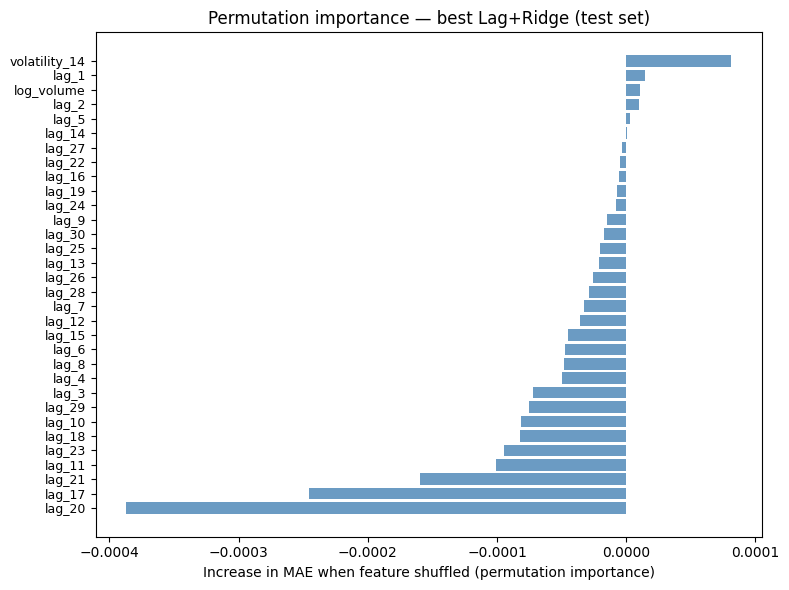

Top 3 features by permutation importance: ['volatility_14', 'lag_1', 'log_volume']
Interpretation: On this run, log_volume and/or volatility_14 rank among the top—shuffling them hurts MAE, so they contribute to point forecasts. Lags in the top 3 indicate which horizon (recent vs mid) the model leans on.


In [11]:
# 5.1 Permutation importance on best Lag+Ridge
from sklearn.inspection import permutation_importance

feature_names = [f"ret_lag_{i}" for i in range(1, N_LAGS + 1)] + ["log_volume", "volatility_14"]
best_model = search.best_estimator_
perm = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, scoring="neg_mean_absolute_error")
perm_mae = -perm.importances_mean  # higher = more important (worse MAE when shuffled)

order = np.argsort(perm_mae)[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(feature_names)), perm_mae[order], color="steelblue", alpha=0.8)
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels([feature_names[i] for i in order], fontsize=9)
ax.set_xlabel("Increase in MAE when feature shuffled (permutation importance)")
ax.set_title("Permutation importance — best Lag+Ridge (test set)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Short interpretation (data-driven from this run)
top3_idx = order[:3]
top3_names = [feature_names[i] for i in top3_idx]
print("Top 3 features by permutation importance:", top3_names)
# Interpret from actual ranking: volume/volatility can rank high when they add unique signal; lags (e.g. lag_1, lag_15) show which time scale matters.
if "log_volume" in top3_names or "volatility_14" in top3_names:
    print("Interpretation: On this run, log_volume and/or volatility_14 rank among the top—shuffling them hurts MAE, so they contribute to point forecasts. Lags in the top 3 indicate which horizon (recent vs mid) the model leans on.")
else:
    print("Interpretation: Recent return lags dominate; the model relies most on the last few days' returns. Extra features (volume, volatility) matter less for point forecasts here.")

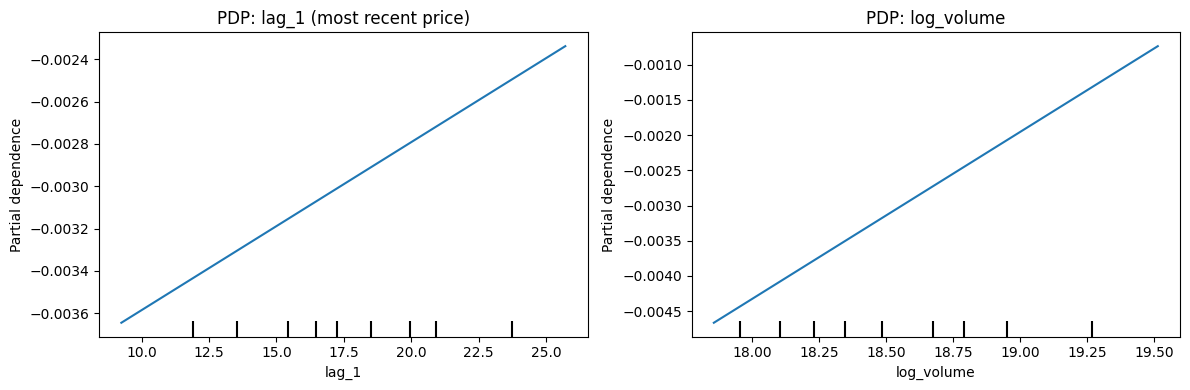

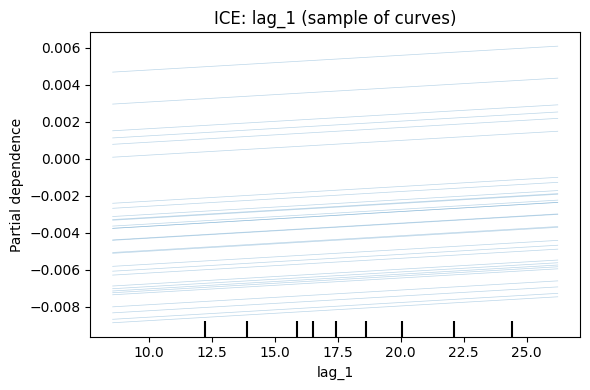

Interpretation: PDP for lag_1 is roughly linear (Ridge is linear in features). Higher lag_1 → higher prediction. log_volume has a flatter PDP. ICE curves show similar slope across samples for lag_1, so effect is fairly homogeneous.


In [12]:
# 5.2 PDP and ICE for 1–2 important features (ret_lag_1 and log_volume)
from sklearn.inspection import PartialDependenceDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# PDP for ret_lag_1 (index 0)
PartialDependenceDisplay.from_estimator(
    best_model, X_test, features=[0], feature_names=feature_names,
    ax=axes[0], kind="average", grid_resolution=50
)
axes[0].set_title("PDP: ret_lag_1 (most recent return)")
# PDP for log_volume (index 30)
PartialDependenceDisplay.from_estimator(
    best_model, X_test, features=[30], feature_names=feature_names,
    ax=axes[1], kind="average", grid_resolution=50
)
axes[1].set_title("PDP: log_volume")
plt.tight_layout()
plt.show()

# ICE for ret_lag_1 (sample of curves for readability)
n_ice = min(30, len(X_test))
X_ice = X_test[:: max(1, len(X_test) // n_ice)][:n_ice]
fig, ax = plt.subplots(figsize=(6, 4))
PartialDependenceDisplay.from_estimator(
    best_model, X_ice, features=[0], feature_names=feature_names,
    ax=ax, kind="individual", grid_resolution=50
)
ax.set_title("ICE: ret_lag_1 (sample of curves)")
plt.tight_layout()
plt.show()
print("Interpretation: PDP for ret_lag_1 shows how yesterday's return affects predicted return. log_volume has a flatter PDP. ICE curves show the effect is fairly homogeneous across samples.")

---
## 5. LSTM

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

SEQ_LEN = 30
price = df["price"].values.astype(np.float64)
T = len(price)
# Returns: r[t] = (price[t+1] - price[t]) / price[t]; length T-1
returns = (price[1:] - price[:-1]) / (price[:-1] + 1e-12)
returns = returns.astype(np.float32)
log_vol = df["log_volume"].values.astype(np.float32)
# Volatility per-split: train uses only train_df; val/test use causal rolling on full series
vol_full = volatility_causal(df["ret"].values).astype(np.float32)  # length T
vol_full = vol_full[1:]  # length T-1 to align with returns
vol_train = np.zeros(len(returns), dtype=np.float32)
vol_train[:train_end] = volatility_causal(train_df["ret"].values).astype(np.float32)[:train_end]
vol_train[train_end:] = vol_full[train_end:]  # val/test: causal from full

def build_seq_multifeature(ret, log_vol, vol, start, end, seq_len):
    """Build sequences [ret, log_volume, volatility] per step; predict next return."""
    X_list = []
    y_list = []
    for i in range(start, min(end, len(ret) - 1)):
        if i >= seq_len:
            X_list.append(np.column_stack([
                ret[i - seq_len : i],
                log_vol[i - seq_len : i],
                vol[i - seq_len : i],
            ]))
            y_list.append(ret[i])
    if not X_list:
        return np.zeros((0, seq_len, 3), dtype=np.float32), np.array([], dtype=np.float32)
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    return X, y

X_tr, y_tr = build_seq_multifeature(returns, log_vol, vol_train, SEQ_LEN, train_end, SEQ_LEN)
X_va, y_va = build_seq_multifeature(returns, log_vol, vol_train, train_end, val_end - 1, SEQ_LEN)
X_te, y_te = build_seq_multifeature(returns, log_vol, vol_train, val_end - 1, T - 1, SEQ_LEN)

# Single scaler fit on train only, reuse for val/test
lstm_scaler = StandardScaler()
n_tr, seq_len, n_feat = X_tr.shape
lstm_scaler.fit(X_tr.reshape(-1, n_feat))
X_tr = lstm_scaler.transform(X_tr.reshape(-1, n_feat)).reshape(-1, seq_len, n_feat).astype(np.float32)
X_va = lstm_scaler.transform(X_va.reshape(-1, n_feat)).reshape(-1, seq_len, n_feat).astype(np.float32)
X_te = lstm_scaler.transform(X_te.reshape(-1, n_feat)).reshape(-1, seq_len, n_feat).astype(np.float32)

# Single LSTM layer, 32 units, strong dropout (less overparameterized for daily signal)
model = keras.Sequential([
    layers.Input(shape=(SEQ_LEN, n_feat)),
    layers.LSTM(32),
    layers.Dropout(0.4),
    layers.Dense(1),
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=30, batch_size=32, verbose=0)

pred_ret = model.predict(X_te, verbose=0).ravel()
m_lstm = metrics_from_returns(y_te, pred_ret)
print("LSTM (1 layer, 32 units, dropout 0.4; target=returns, vol per-split):", m_lstm)

LSTM (1 layer, 32 units, dropout 0.4; target=returns, vol per-split): {'mae': 0.030244531109929085, 'rmse': 0.04248429462313652, 'directional_accuracy': 0.5088105726872246}


---
## 6. Comparison table

In [14]:
# Use best Lag+Ridge from CV (Section 3d) for fair comparison
rows = [
    ["Last value", m_last["mae"], m_last["rmse"], m_last["directional_accuracy"]],
    ["7-day MA", m_ma["mae"], m_ma["rmse"], m_ma["directional_accuracy"]],
    ["Lag+Ridge (best CV)", metrics_best["mae"], metrics_best["rmse"], metrics_best["directional_accuracy"]],
    ["LSTM", m_lstm["mae"], m_lstm["rmse"], m_lstm["directional_accuracy"]],
]
print(pd.DataFrame(rows, columns=["Model", "MAE", "RMSE", "Dir.Acc"]).to_string(index=False))

              Model      MAE     RMSE  Dir.Acc
         Last value 0.030161 0.042382 0.000000
           7-day MA 0.046755 0.063237 0.555804
Lag+Ridge (best CV) 0.029415 0.041424 0.530660
               LSTM 0.030245 0.042484 0.508811


---
## 6b. Long/short backtest with transaction costs

Simple strategy: go long when predicted return > threshold, short when < -threshold, else flat. Apply a transaction cost per trade. Many models with higher MAE can still outperform in PnL once direction and turnover are considered.

In [15]:
def backtest_long_short(actual_ret, pred_ret, threshold=0.0, cost_bps=10):
    """
    Long/short backtest: long when pred > threshold, short when pred < -threshold.
    actual_ret, pred_ret: arrays of length T. cost_bps: transaction cost in basis points per trade.
    """
    actual_ret = np.asarray(actual_ret).ravel()
    pred_ret = np.asarray(pred_ret).ravel()
    position = 0  # -1 short, 0 flat, 1 long
    pnl = 0.0
    n_trades = 0
    cost_per_trade = cost_bps / 10000.0
    for t in range(len(actual_ret)):
        signal = 1 if pred_ret[t] > threshold else (-1 if pred_ret[t] < -threshold else 0)
        if signal != position:
            n_trades += 1
            pnl -= cost_per_trade  # pay cost when changing position
            position = signal
        pnl += position * actual_ret[t]  # PnL from position * realized return
    return pnl, n_trades

# Backtest on test set: best Lag+Ridge and LSTM
threshold = 0.0  # tune to trade off turnover vs signal
cost_bps = 10   # 10 bps per trade
pnl_ridge, trades_ridge = backtest_long_short(y_test, pred_lag_best_ret, threshold=threshold, cost_bps=cost_bps)
pnl_lstm, trades_lstm = backtest_long_short(y_test, pred_ret, threshold=threshold, cost_bps=cost_bps)
# Buy-and-hold (long only, no cost at start for simplicity)
bh_ret = np.sum(y_test)

print("Backtest (test set, threshold=%.2f, cost=%d bps):" % (threshold, cost_bps))
print("  Lag+Ridge:  PnL (cum return) = %.4f  |  trades = %d" % (pnl_ridge, trades_ridge))
print("  LSTM:       PnL (cum return) = %.4f  |  trades = %d" % (pnl_lstm, trades_lstm))
print("  Buy-and-hold (long): cum return = %.4f" % bh_ret)
print("(PnL and B&H are in return space; multiply by 100 for approximate %.)")

Backtest (test set, threshold=0.00, cost=10 bps):
  Lag+Ridge:  PnL (cum return) = 0.2654  |  trades = 38
  LSTM:       PnL (cum return) = -0.5531  |  trades = 112
  Buy-and-hold (long): cum return = -0.7145
(PnL and B&H are in return space; multiply by 100 for approximate %.)


---
## 7. 7-day MA forecast for the future

Use the last 7 observed prices to predict the next day. For further ahead, roll forward: each new day's 7-day MA uses the last 6 known values plus your previous forecast.

In [16]:
WINDOW = 7
# Last 7 observed prices (from full dataset - use latest data in production)
last_prices = df["price"].values[-WINDOW:]
next_day_ma = np.mean(last_prices)
print("Last 7 prices:", last_prices.round(4))
print("7-day MA forecast for next day:", round(next_day_ma, 4))

# Optional: multi-step 7-day MA for the next N days (roll forward)
# Each new day: predict = mean(last 7), where "last 7" includes previous forecasts
def forecast_7day_ma_future(prices, steps=7):
    """Roll forward: each step uses last 6 of window + 1 new forecast (mean of window)."""
    window = list(prices[-WINDOW:].tolist())
    preds = []
    for _ in range(steps):
        pred = np.mean(window)
        preds.append(pred)
        window = window[1:] + [pred]
    return np.array(preds)

future_ma = forecast_7day_ma_future(df["price"].values, steps=7)
print("\n7-day MA forecasts for next 7 days:", future_ma.round(4))

Last 7 prices: [9.0369 8.5187 8.3538 8.2959 9.1251 8.8646 8.6142]
7-day MA forecast for next day: 8.687

7-day MA forecasts for next 7 days: [8.687  8.637  8.6539 8.6968 8.7541 8.7011 8.6777]
